In [21]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

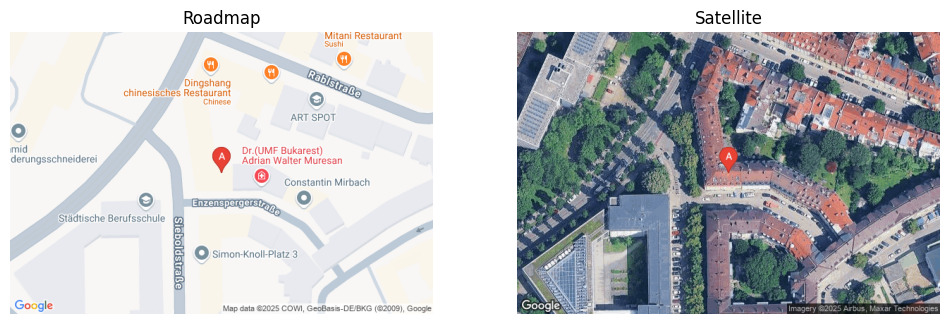

In [22]:
def generate_static_maps_url(address, api_key, maptype, zoom=18, size="600x400"):
    """Generates URL for Google Static Maps API."""
    basis_url = "https://maps.googleapis.com/maps/api/staticmap?"
    parameter = {
        "center": address,
        "zoom": zoom,
        "size": size,
        "markers": f"color:red|label:A|{address}",
        "key": api_key,
        "maptype": maptype
    }
    url_parameter = "&".join([f"{key}={value}" for key, value in parameter.items()])
    return basis_url + url_parameter

with open("api_key.txt", "r") as f:
    api_key =  f.read().strip()
address = input("Insert the wished adress: ")

# Roadmap image
static_maps_url_roadmap = generate_static_maps_url(address, api_key, "roadmap")
response_roadmap = requests.get(static_maps_url_roadmap)
response_roadmap.raise_for_status()
image_data_roadmap = response_roadmap.content

# Satellite image
static_maps_url_satellite = generate_static_maps_url(address, api_key, "satellite")
response_satellite = requests.get(static_maps_url_satellite)
response_satellite.raise_for_status()
image_data_satellite = response_satellite.content

# Display the images
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].set_title("Roadmap")
axs[0].axis('off')
axs[0].imshow(mpimg.imread(BytesIO(image_data_roadmap)))
axs[1].set_title("Satellite")
axs[1].axis('off')
axs[1].imshow(mpimg.imread(BytesIO(image_data_satellite)))
plt.show()

/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_58885/2581223058.py:13: RuntimeWarning: overflow encountered in scalar subtract
  if (abs(pixel_farbe[0] - target_color[0]) < tolerance and
/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_58885/2581223058.py:14: RuntimeWarning: overflow encountered in scalar subtract
  abs(pixel_farbe[1] - target_color[1]) < tolerance and
/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_58885/2581223058.py:15: RuntimeWarning: overflow encountered in scalar subtract
  abs(pixel_farbe[2] - target_color[2]) < tolerance):


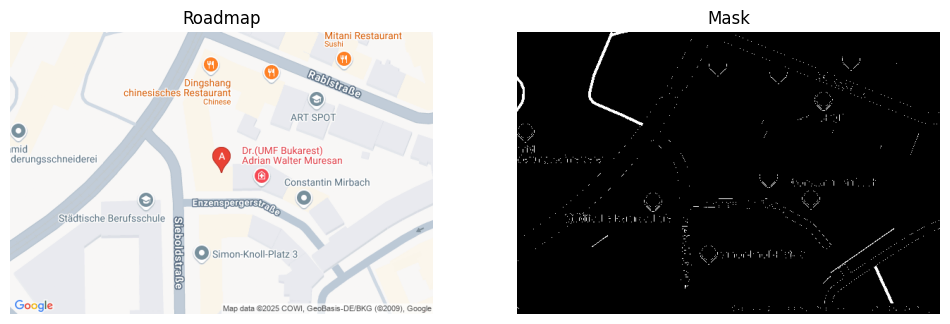

In [23]:
# RGB comparison with tolerance

# Create mask out of the roadmap image: road = 1, no road = 0
def generate_streat_mask(image_data_roadmap, target_color=(195, 202, 210), tolerance=20):
    """Generate mask of pixels similar to a road."""
    img = Image.open(BytesIO(image_data_roadmap)).convert("RGB")
    img_array = np.array(img)
    mask = np.zeros(img_array.shape[:2], dtype=np.uint8)  # Graustufenmaske (0 oder 255)

    for y in range(img_array.shape[0]):
        for x in range(img_array.shape[1]):
            pixel_farbe = img_array [y, x]
            if (abs(pixel_farbe[0] - target_color[0]) < tolerance and
                    abs(pixel_farbe[1] - target_color[1]) < tolerance and
                    abs(pixel_farbe[2] - target_color[2]) < tolerance):
                mask[y, x] = 255  # Setze Pixel auf Weiß (1 in der binären Interpretation)

    return mask

roadmap_mask = generate_streat_mask(image_data_roadmap)

# show mask
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].set_title("Roadmap")
axs[0].axis('off')
axs[0].imshow(mpimg.imread(BytesIO(image_data_roadmap)))
axs[1].set_title("Mask")
axs[1].axis('off')
axs[1].imshow(roadmap_mask, cmap='gray')
plt.show()

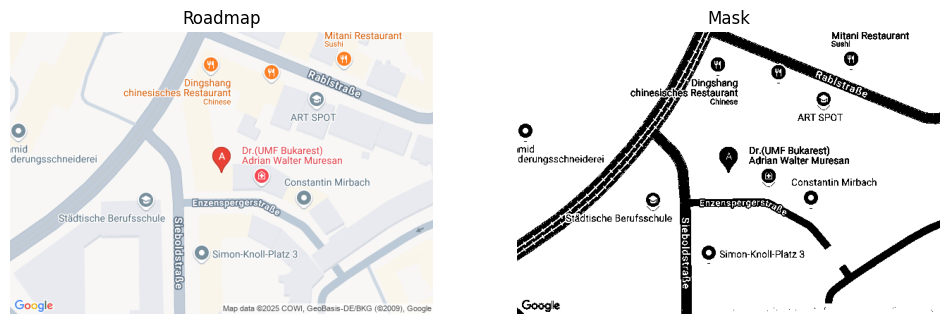

In [24]:
# Grayscale comparison with HSV

import cv2

def generate_street_mask_grayscale_hsv(image_data, saturation_threshold=0.1):
    """Generates a mask for grayscale pixels based on HSV saturation."""
    img_pil = Image.open(BytesIO(image_data)).convert("RGB")
    img_cv = np.array(img_pil)
    hsv_img = cv2.cvtColor(img_cv, cv2.COLOR_RGB2HSV)
    saturation = hsv_img[:, :, 1].astype(float) / 255.0  # Normalize saturation channel

    mask = (saturation < saturation_threshold).astype(np.uint8) * 255
    return mask

roadmap_mask = generate_street_mask_grayscale_hsv(image_data_roadmap)

# show mask
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].set_title("Roadmap")
axs[0].axis('off')
axs[0].imshow(mpimg.imread(BytesIO(image_data_roadmap)))
axs[1].set_title("Mask")
axs[1].axis('off')
axs[1].imshow(roadmap_mask, cmap='gray')
plt.show()

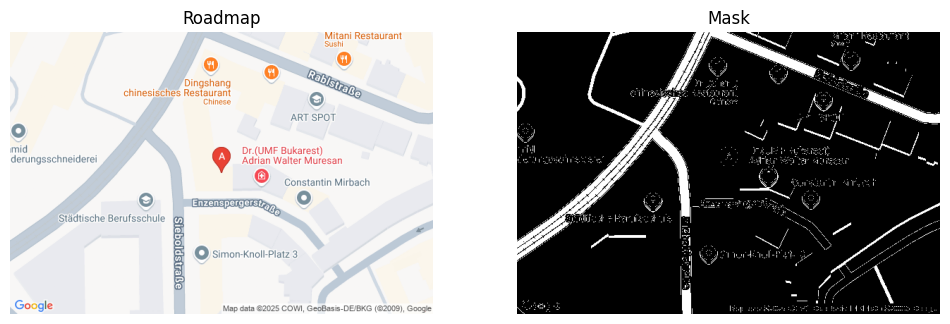

In [25]:
# Grayscale comparison with brightness

def generate_street_mask_grayscale_brightness(image_data, lower_threshold=200, upper_threshold=230):
    """Generates a mask for pixels within a specific grayscale brightness range."""
    img_pil = Image.open(BytesIO(image_data)).convert("L")  # Convert to grayscale ('L' mode)
    img_array = np.array(img_pil)

    mask = ((img_array >= lower_threshold) & (img_array <= upper_threshold)).astype(np.uint8) * 255
    return mask

roadmap_mask = generate_street_mask_grayscale_brightness(image_data_roadmap)

# show mask
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].set_title("Roadmap")
axs[0].axis('off')
axs[0].imshow(mpimg.imread(BytesIO(image_data_roadmap)))
axs[1].set_title("Mask")
axs[1].axis('off')
axs[1].imshow(roadmap_mask, cmap='gray')
plt.show()